# NeuroDetect — Demo: Brain Tumor Prediction
**Course**: Computer Vision | Christian Mata, PhD

**Requires**: 02_classification_TL and 03_segmentation must have run first so the models are saved to Drive.

**Group members**: Martin Çaro, Edison Zyberaj


## 1. Mount Drive and load models

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/CV_Project'
print('Drive mounted ✓')

Mounted at /content/drive
Drive mounted ✓


In [3]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

class CompatBatchNorm(tf.keras.layers.BatchNormalization):
    def __init__(self, **kwargs):
        kwargs.pop('renorm',          None)
        kwargs.pop('renorm_clipping', None)
        kwargs.pop('renorm_momentum', None)
        super().__init__(**kwargs)

    @classmethod
    def from_config(cls, config):
        config.pop('renorm',          None)
        config.pop('renorm_clipping', None)
        config.pop('renorm_momentum', None)
        return super().from_config(config)

custom_objects = {'BatchNormalization': CompatBatchNorm}

# ── Load models ───────────────────────────────────────────────────────────────
assert os.path.exists(DRIVE + '/models/brain_tumor_classifier.h5'), \
    '❌ Run 02_classification.ipynb first.'
assert os.path.exists(DRIVE + '/models/brain_tumor_tl_classifier.h5'), \
    '❌ Run transfer learning section in 02_classification.ipynb first.'
assert os.path.exists(DRIVE + '/models/brain_tumor_segmenter.h5'), \
    '❌ Run 03_segmentation.ipynb first.'

print('Loading models from Drive...')
clf_model = tf.keras.models.load_model(
    DRIVE + '/models/brain_tumor_classifier.h5',
    compile=False
)
tl_model  = tf.keras.models.load_model(
    DRIVE + '/models/brain_tumor_tl_classifier.h5',
    custom_objects=custom_objects,
    compile=False
)
seg_model = tf.keras.models.load_model(
    DRIVE + '/models/brain_tumor_segmenter.h5',
    custom_objects=custom_objects,
    compile=False
)

print('Classifier loaded      ✓')
print('Transfer model loaded  ✓')
print('Segmenter loaded       ✓')

label_names = ['no tumor', 'tumor']

# Find last Conv2D layer for Grad-CAM
last_conv = next(
    layer.name for layer in reversed(clf_model.layers)
    if isinstance(layer, tf.keras.layers.Conv2D)
)
print(f'Last Conv2D layer: {last_conv}')

Loading models from Drive...
Classifier loaded      ✓
Transfer model loaded  ✓
Segmenter loaded       ✓
Last Conv2D layer: conv2d_1


## 2. Grad-CAM and overlay functions

In [4]:
def make_gradcam_heatmap(image, model, last_conv_layer_name, pred_index=None):
    image_batch = tf.cast(image[np.newaxis, ...], tf.float32)

    with tf.GradientTape() as tape:
        x            = image_batch
        conv_outputs = None
        for layer in model.layers:
            x = layer(x)
            if layer.name == last_conv_layer_name:
                conv_outputs = x
                tape.watch(conv_outputs)
        predictions = x
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(image, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], (image.shape[0], image.shape[1])
    ).numpy().squeeze()
    colored = plt.cm.jet(heatmap_resized)[..., :3]
    return np.clip((1 - alpha) * np.clip(image, 0, 1) + alpha * colored, 0, 1)

# Force Keras to trace the graph
dummy = np.zeros((1, 128, 128, 3), dtype=np.float32)
_ = clf_model.predict(dummy, verbose=0)
print('Grad-CAM functions ready ✓')

Grad-CAM functions ready ✓


## 3. Upload your MRI image

In [5]:
from google.colab import files

print('Please upload a brain MRI image (JPG or PNG):')
uploaded   = files.upload()
image_path = list(uploaded.keys())[0]
print(f'Uploaded: {image_path}')

Please upload a brain MRI image (JPG or PNG):


Saving TCGA_CS_4941_19960909_3.png to TCGA_CS_4941_19960909_3.png
Uploaded: TCGA_CS_4941_19960909_3.png


## 4. Preprocess

Image shape : (128, 128, 3)
Pixel range : 0.00 – 0.89


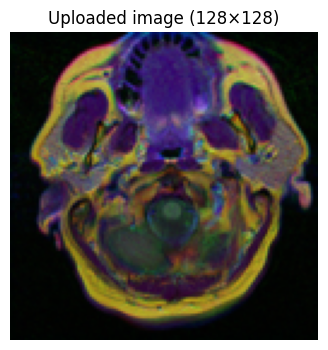

In [6]:
img = np.array(
    Image.open(image_path).convert('RGB').resize((128, 128)),
    dtype=np.float32
) / 255.0

print(f'Image shape : {img.shape}')
print(f'Pixel range : {img.min():.2f} – {img.max():.2f}')

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title('Uploaded image (128×128)')
plt.axis('off')
plt.show()

## 5. Run the full pipeline

Baseline CNN:      NO TUMOR  (100.0%)
Transfer Learning: NO TUMOR   (83.5%)


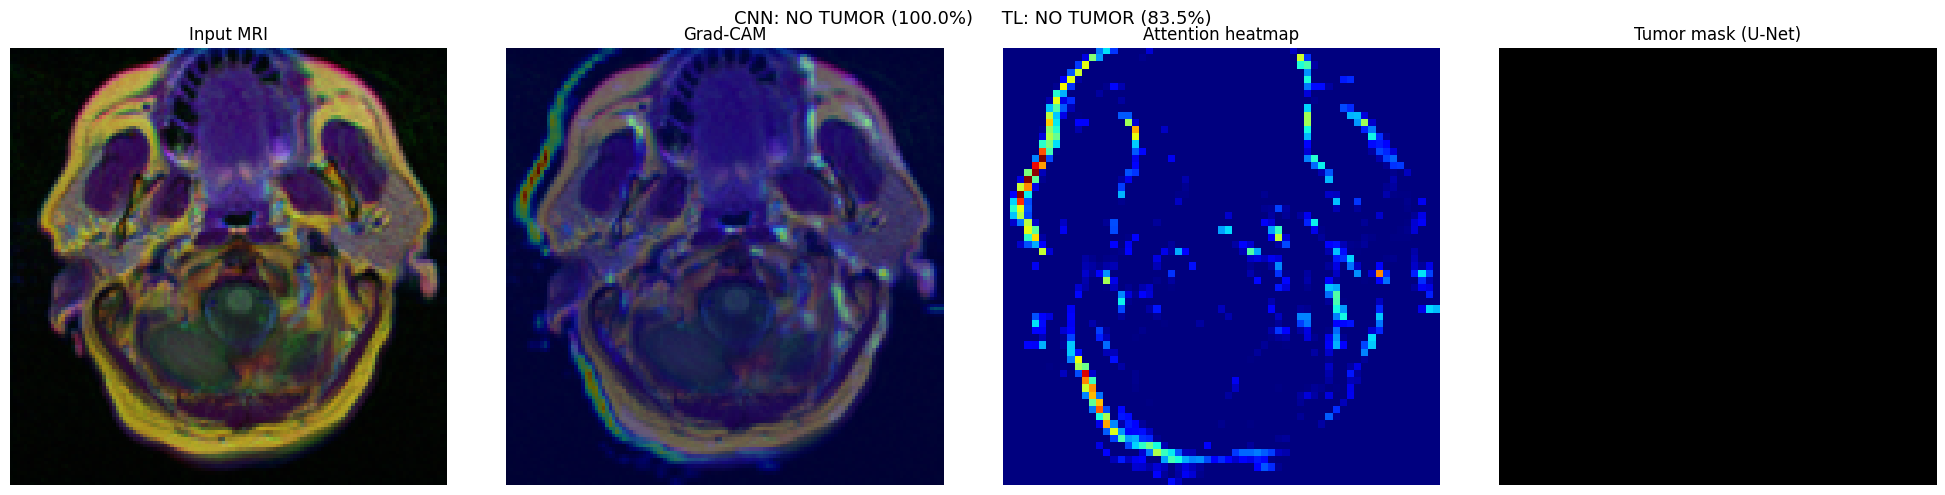

Result saved to Drive ✓


In [7]:
# ── Preprocess for TL ──────────────────────────
img_tl = (img * 2.0 - 1.0).astype(np.float32)

# ── Baseline CNN prediction ───────────────────────────────────────────────────
probs_cnn  = clf_model.predict(img[np.newaxis, ...], verbose=0)[0]
label_cnn  = 'TUMOR DETECTED' if np.argmax(probs_cnn) == 1 else 'NO TUMOR'
conf_cnn   = probs_cnn.max() * 100

# ── Transfer Learning prediction ─────────────────────────────────────────────
probs_tl   = tl_model.predict(img_tl[np.newaxis, ...], verbose=0)[0]
label_tl   = 'TUMOR DETECTED' if np.argmax(probs_tl) == 1 else 'NO TUMOR'
conf_tl    = probs_tl.max() * 100

print(f'Baseline CNN:      {label_cnn}  ({conf_cnn:.1f}%)')
print(f'Transfer Learning: {label_tl}   ({conf_tl:.1f}%)')

# ── Grad-CAM using baseline CNN ───────────────────────────────────────────────
heatmap = make_gradcam_heatmap(img, clf_model, last_conv)
overlay = overlay_heatmap(img, heatmap)

# ── U-Net segmentation mask ───────────────────────────────────────────────────
logits    = seg_model.predict(img[np.newaxis, ...], verbose=0)[0]
pred_mask = np.argmax(logits, axis=-1)

# ── Display ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    f'CNN: {label_cnn} ({conf_cnn:.1f}%)     '
    f'TL: {label_tl} ({conf_tl:.1f}%)',
    fontsize=13
)

axes[0].imshow(img);                     axes[0].set_title('Input MRI');         axes[0].axis('off')
axes[1].imshow(overlay);                 axes[1].set_title('Grad-CAM');           axes[1].axis('off')
axes[2].imshow(heatmap, cmap='jet');     axes[2].set_title('Attention heatmap');  axes[2].axis('off')
axes[3].imshow(pred_mask, cmap='gray');  axes[3].set_title('Tumor mask (U-Net)'); axes[3].axis('off')

plt.tight_layout()
plt.savefig(DRIVE + '/results/demo_output.png', dpi=120)
plt.show()
print('Result saved to Drive ✓')

## 6. What the output shows

**Input MRI** — the uploaded image resized to 128×128. The three colour channels are the pre-contrast, FLAIR, and post-contrast MRI sequences displayed as RGB, which is why the image looks colourful rather than grayscale.

**Grad-CAM overlay** — the original image with the attention heatmap blended on top. Warm colours (red/yellow) show which regions of the scan most influenced the classification decision. If the model detects a tumor, these warm regions should correspond to the abnormal area.

**Attention heatmap** — the raw Grad-CAM heatmap without the original image underneath, shown in the jet colourmap. Red = highest attention, blue = lowest.

**Tumor mask (U-Net)** — the pixel-wise segmentation produced by the U-Net. White pixels are classified as tumor, black as background. This is independent of the classifier — the U-Net always draws a mask regardless of what the CNN decided, so compare the two outputs to see whether they agree on the location of the abnormal region.